<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EB%B0%95%EC%84%9C%ED%98%84/ELEalgo_random_forest%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Config

In [3]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error

RF_CONFIG = {
    "n_estimators": 100,
    "max_depth": None,
    "random_seed": 42,
    "n_jobs": -1
}

# Feature 설정

In [4]:
CSV_FILENAME = "merged_features_25C.csv"

FEATURES = ["variance", "xmean", "mean3839", "mean3940", "mean4041", "mean4142",
            "max", "min", "range", "stdev", "dcirohm",
            "dcir_soc00ohm", "dcir_soc10ohm", "dcir_soc20ohm", "dcir_soc30ohm",
            "dcir_soc40ohm", "dcir_soc50ohm", "dcir_soc60ohm",
            "dcir_soc70ohm", "dcir_soc80ohm",
            "deltat023840", "deltat103840", "ctr", "ccct", "cvct"]

TARGET = "soh_label_pct"

df = pd.read_csv(CSV_FILENAME)

X = df[FEATURES]
y = df[TARGET]
groups = df["cell_global_id"]

print("전체 데이터:", len(df))
print("전체 Cell:", groups.nunique())

전체 데이터: 141
전체 Cell: 24


# Dataset Split
Train 8 / Test 2

In [5]:
split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RF_CONFIG["random_seed"])

train_idx, test_idx = next(
    split.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("Train:", len(X_train), "rows /", train_groups.nunique(), "cells")
print("Test :", len(X_test), "rows /", test_groups.nunique(), "cells")

Train: 109 rows / 19 cells
Test : 32 rows / 5 cells


# Random Forest 학습
Decision Tree 100개 사용 (Config에서 지정)

In [6]:
rf_model = RandomForestRegressor(
    n_estimators=RF_CONFIG["n_estimators"],
    max_depth=RF_CONFIG["max_depth"],
    random_state=RF_CONFIG["random_seed"],
    n_jobs=RF_CONFIG["n_jobs"])

print("Random Forest 학습 시작")

rf_model.fit(X_train, y_train)

print("Random Forest 학습 완료")

Random Forest 학습 시작
Random Forest 학습 완료


# Test Loss
Loss: MSE

In [7]:
test_predictions = rf_model.predict(X_test)

test_loss = mean_squared_error(
    y_test,test_predictions)

print("Test Loss (MSE):", round(test_loss, 4))

Test Loss (MSE): 0.1499


# Feature Importance
Random Forest가 SOH 예측할 때 어떤 Feature를 상대적으로 많이 사용했는지 보여주는 값

In [8]:
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False)

print(importance_df.to_string(index=False))

      Feature  Importance
         ccct    0.727742
 deltat103840    0.119050
      dcirohm    0.053555
     variance    0.028238
     mean3839    0.021513
 deltat023840    0.018776
        range    0.010344
dcir_soc80ohm    0.007925
          max    0.002991
        stdev    0.001613
          ctr    0.001446
dcir_soc60ohm    0.001427
dcir_soc40ohm    0.000777
     mean4142    0.000776
dcir_soc00ohm    0.000754
          min    0.000475
     mean4041    0.000430
dcir_soc50ohm    0.000352
        xmean    0.000325
         cvct    0.000311
dcir_soc30ohm    0.000309
dcir_soc20ohm    0.000285
     mean3940    0.000259
dcir_soc10ohm    0.000199
dcir_soc70ohm    0.000129


# Actual vs Predicted
실제 SOH와 예측 SOH가 얼마나 잘 맞는지, 특정 구간에서 편향이 있는지 확인

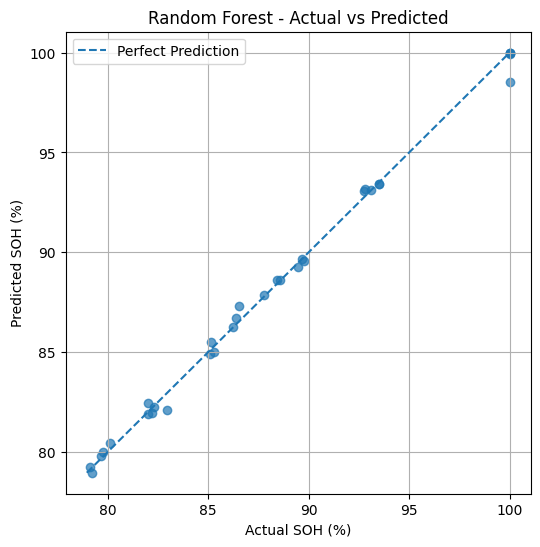

In [12]:
import matplotlib.pyplot as plt

test_predictions = rf_model.predict(X_test)
actuals = y_test.to_numpy()

plt.figure(figsize=(6, 6))

plt.scatter(actuals, test_predictions, alpha=0.7)

min_value = min(actuals.min(), test_predictions.min())
max_value = max(actuals.max(), test_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Random Forest - Actual vs Predicted")

plt.legend()
plt.grid()

plt.show()